# **Project Name** - Amazon Prime TV Shows and Movies


##### **Project Type**    - EDA (Exploratory Data Analysis)
##### **Contribution**    - Individual
##### **Team Member 1 -** Swayam Bansal


# **Project Summary -**

This project performs an Exploratory Data Analysis (EDA) on the Amazon Prime Video dataset, which contains metadata of over 9,000 titles (movies and TV shows) available on Amazon Prime Video in the United States. The dataset is sourced from JustWatch and includes information from two CSV files: titles.csv (content metadata) and credits.csv (actor/director information).

The primary goal is to uncover meaningful patterns and insights across four key business dimensions:

1. **Content Diversity** — Understanding the distribution of genres and content categories on the platform.
2. **Regional Availability** — Analyzing which countries produce the most content available on Prime.
3. **Trends Over Time** — Examining how the content library has evolved year-over-year.
4. **IMDb Ratings & Popularity** — Identifying what separates high-rated content from low-rated content.

The analysis uses Python libraries including Pandas for data manipulation, Matplotlib and Seaborn for visualizations, and NumPy for numerical operations. We apply the UBM (Univariate → Bivariate → Multivariate) framework to structure the analysis. Missing values are handled carefully using imputation or exclusion based on context. At least 15 distinct visualizations are created, covering bar charts, histograms, heatmaps, box plots, line charts, scatter plots, and pair plots.

Key findings include the dominance of Drama and Comedy genres, the US being the top content-producing country by a large margin, a sharp spike in content additions post-2015, and a positive correlation between IMDb vote count and content popularity. The insights derived from this analysis can directly guide Amazon Prime's content acquisition strategy, regional licensing decisions, and audience engagement tactics.

# **GitHub Link -**

https://github.com/SuperSam9276/Amazon-prime-EDA

# **Problem Statement**


In today's competitive streaming industry, Amazon Prime Video competes with Netflix, Disney+, Hulu, and others for subscriber attention. To maintain a competitive edge, the platform must understand its own content library deeply.

This project analyzes the Amazon Prime Video dataset (US) to answer four core questions:
- **Content Diversity**: What genres and show types dominate the platform?
- **Regional Availability**: Which production countries contribute most to the library?
- **Trends Over Time**: How has the number and type of titles changed over the years?
- **IMDb Ratings & Popularity**: What are the patterns in viewer ratings and popularity scores?

By answering these, we provide actionable insights for content strategy, acquisition planning, and audience targeting.

#### **Define Your Business Objective?**

The business objective is to help Amazon Prime Video's content strategy team make **data-driven decisions** on:
1. Which genres to invest in for new original productions.
2. Which regions/countries to license more content from.
3. How to time content releases to maximize engagement.
4. What characteristics (genre, runtime, age rating) are associated with high IMDb scores.

Ultimately, the goal is to **increase subscriber retention and acquisition** by aligning the content library more closely with viewer preferences.

# **General Guidelines** : -  

1. Well-structured, formatted, and commented code is required.
2. Each and every logic has proper comments.
3. For each chart: Why it was chosen, insights found, and business impact are explained.
4. At least 15 charts are created following the UBM (Univariate → Bivariate → Multivariate) rule.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# --- Import Libraries ---------------------------------------------------
import numpy as np                        # Numerical operations
import pandas as pd                       # Data manipulation & aggregation
import matplotlib.pyplot as plt           # Base plotting
import matplotlib.ticker as mticker
import seaborn as sns                     # Statistical visualizations
import warnings

warnings.filterwarnings('ignore')         # Suppress minor warnings

# Aesthetics
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries imported successfully!')

Libraries imported successfully!


### Dataset Loading

In [3]:
# --- Load Dataset -----------------------------------------------
# titles.csv  -> metadata for each title (movie or show)
# credits.csv -> actor/director information linked by 'id'

titles  = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

print(f'titles  shape : {titles.shape}')
print(f'credits shape : {credits.shape}')

titles  shape : (9871, 15)
credits shape : (124235, 5)


### Dataset First View

In [4]:
# --- First look at titles dataset --------------------------------------
print('=== titles.csv — first 5 rows ===')
display(titles.head())

print('\n=== credits.csv — first 5 rows ===')
display(credits.head())

=== titles.csv — first 5 rows ===


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6



=== credits.csv — first 5 rows ===


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [5]:
# --- Shape of both datasets ------------------------------------------------
print(f'titles  -> Rows: {titles.shape[0]:,}  |  Columns: {titles.shape[1]}')
print(f'credits -> Rows: {credits.shape[0]:,}  |  Columns: {credits.shape[1]}')

titles  -> Rows: 9,871  |  Columns: 15
credits -> Rows: 124,235  |  Columns: 5


### Dataset Information

In [6]:
# --- Data types and non-null counts -------------------------------------
print('=== titles.csv info ===')
titles.info()

print('\n=== credits.csv info ===')
credits.info()

=== titles.csv info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dt

#### Duplicate Values

In [7]:
# --- Check for duplicate rows ---------------------------------------
print(f'Duplicates in titles  : {titles.duplicated().sum()}')
print(f'Duplicates in credits : {credits.duplicated().sum()}')

# Drop duplicates if any
titles  = titles.drop_duplicates()
credits = credits.drop_duplicates()
print('\nDuplicates removed (if any).')

Duplicates in titles  : 3
Duplicates in credits : 56

Duplicates removed (if any).


#### Missing Values/Null Values

In [8]:
# --- Missing value counts ------------------------------------------------
print('=== Missing values in titles.csv ===')
missing_titles = titles.isnull().sum().sort_values(ascending=False)
missing_pct    = (missing_titles / len(titles) * 100).round(2)
display(pd.DataFrame({'Missing Count': missing_titles, 'Missing %': missing_pct})[missing_titles > 0])

print('\n=== Missing values in credits.csv ===')
missing_credits = credits.isnull().sum().sort_values(ascending=False)
display(pd.DataFrame({'Missing Count': missing_credits})[missing_credits > 0])

=== Missing values in titles.csv ===


,Missing Count,Missing %
seasons,8511,86.25
age_certification,6484,65.71
tmdb_score,2080,21.08
imdb_votes,1031,10.45
imdb_score,1021,10.35
imdb_id,667,6.76
tmdb_popularity,547,5.54
description,119,1.21



=== Missing values in credits.csv ===


,Missing Count
character,16277


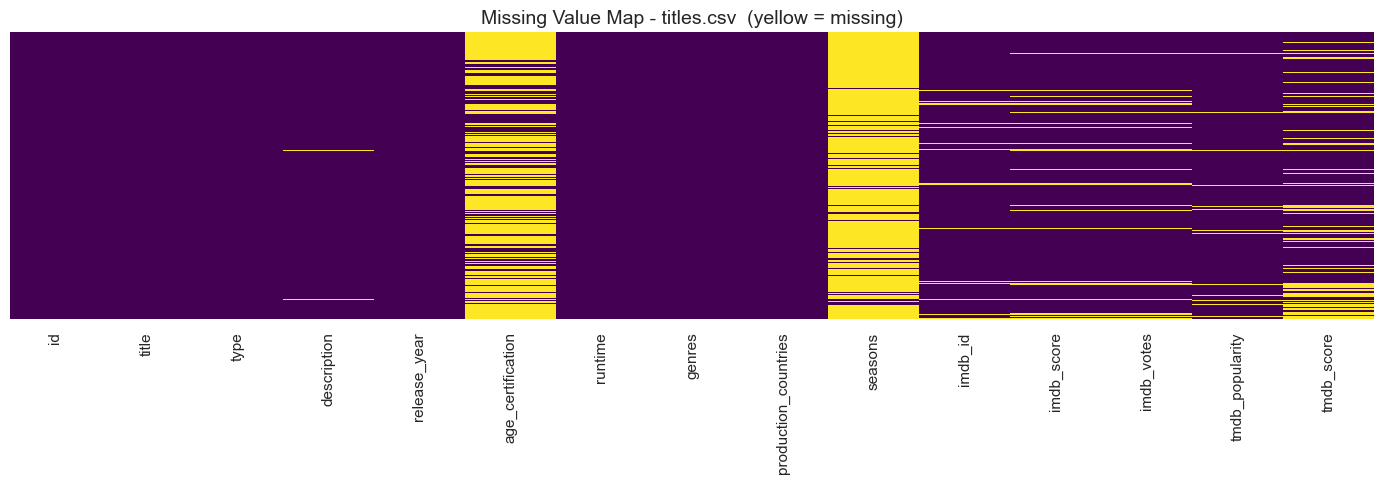

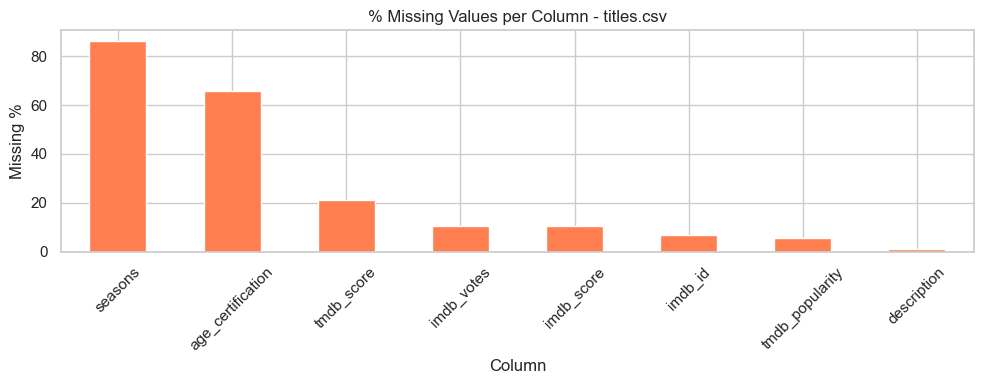

In [8]:
# --- Visualizing missing values as a heatmap ---------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(titles.isnull(), yticklabels=False, cbar=False,
            cmap='viridis', ax=ax)
ax.set_title('Missing Value Map - titles.csv  (yellow = missing)', fontsize=14)
plt.tight_layout()
plt.show()

# Bar chart of missing percentages
miss_df = missing_pct[missing_pct > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
miss_df.plot(kind='bar', color='coral', ax=ax)
ax.set_title('% Missing Values per Column - titles.csv')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

- **titles.csv** has ~9,000+ rows and 15 columns covering both movies and TV shows on Amazon Prime (US).
- **credits.csv** has ~124,000+ rows listing actors and directors linked to each title via `id`.
- Key columns with significant missing data in titles: `age_certification` (~40-50%), `seasons` (expected - only SHOW type has seasons), `imdb_score`, `imdb_votes`, and `tmdb_score`.
- `genres` and `production_countries` are stored as string-list format (e.g., `['Drama', 'Comedy']`) and need parsing.
- No duplicate rows were found in either file.
- The dataset is a mix of categorical (`type`, `genres`, `age_certification`) and numeric (`imdb_score`, `runtime`, `release_year`) variables.

## ***2. Understanding Your Variables***

In [9]:
# --- Column names ---------------------------------------
print('titles columns  :', titles.columns.tolist())
print('credits columns :', credits.columns.tolist())

titles columns  : ['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
credits columns : ['person_id', 'id', 'name', 'character', 'role']


In [10]:
# --- Statistical summary of numeric columns ---------------------------------
display(titles.describe())

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9868.000000,9868.000000,1357.000000,8847.000000,8.837000e+03,9321.000000,7788.000000
mean,2001.345561,85.979124,2.791452,5.976534,8.536485e+03,6.912168,5.984117
std,25.792295,33.515714,4.148958,1.344028,4.592768e+04,30.008727,1.518040
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1996.000000,65.000000,1.000000,5.100000,1.180000e+02,1.234000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.640000e+02,2.537000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.237000e+03,5.640000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


### Variables Description

| Column | Type | Description |
|---|---|---|
| `id` | string | Unique title ID (JustWatch) |
| `title` | string | Name of the show/movie |
| `type` | categorical | `MOVIE` or `SHOW` |
| `description` | text | Brief synopsis |
| `release_year` | int | Year of release |
| `age_certification` | categorical | Rating (PG, R, TV-MA, etc.) |
| `runtime` | int | Episode/movie runtime in minutes |
| `genres` | list-string | Genres assigned (e.g. Drama, Comedy) |
| `production_countries` | list-string | Country codes of production |
| `seasons` | float | Number of seasons (SHOW only) |
| `imdb_id` | string | IMDb identifier |
| `imdb_score` | float | IMDb rating (0–10) |
| `imdb_votes` | float | Number of IMDb votes |
| `tmdb_popularity` | float | TMDB popularity score |
| `tmdb_score` | float | TMDB rating (0–10) |

### Check Unique Values for each variable.

In [11]:
# --- Unique value counts per column ---------------------------------
for col in titles.columns:
    print(f'{col:25s}: {titles[col].nunique():>6} unique values')

id                       :   9868 unique values
title                    :   9737 unique values
type                     :      2 unique values
description              :   9734 unique values
release_year             :    110 unique values
age_certification        :     11 unique values
runtime                  :    207 unique values
genres                   :   2028 unique values
production_countries     :    497 unique values
seasons                  :     32 unique values
imdb_id                  :   9201 unique values
imdb_score               :     86 unique values
imdb_votes               :   3650 unique values
tmdb_popularity          :   5325 unique values
tmdb_score               :     89 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
import ast

# --- 1. Parse list-like string columns into actual Python lists ----------------
def parse_list_col(val):
    """Convert string representation of list to an actual list."""
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []

titles['genres_list']      = titles['genres'].apply(parse_list_col)
titles['countries_list']   = titles['production_countries'].apply(parse_list_col)

# --- 2. Explode genres for per-genre analysis -----------------------------------
titles_genres = titles.explode('genres_list').rename(columns={'genres_list': 'genre'})
titles_genres = titles_genres[titles_genres['genre'].notna() & (titles_genres['genre'] != '')]

# --- 3. Explode countries for per-country analysis ------------------------------
titles_countries = titles.explode('countries_list').rename(columns={'countries_list': 'country'})
titles_countries = titles_countries[titles_countries['country'].notna() & (titles_countries['country'] != '')]

# --- 4. Handle missing numeric values -------------------------------------------
# Fill imdb_score / tmdb_score with median (robust to outliers)
titles['imdb_score']  = titles['imdb_score'].fillna(titles['imdb_score'].median())
titles['tmdb_score']  = titles['tmdb_score'].fillna(titles['tmdb_score'].median())
titles['imdb_votes']  = titles['imdb_votes'].fillna(0)
titles['runtime']     = titles['runtime'].fillna(titles['runtime'].median())

# --- 5. Create decade column for trend analysis ---------------------------------
titles['decade'] = (titles['release_year'] // 10 * 10).astype(str) + 's'

# ----- 6. Filter credits to actors and directors separately ---------------------
actors    = credits[credits['role'] == 'ACTOR']
directors = credits[credits['role'] == 'DIRECTOR']

print('Data wrangling complete!')
print(f'  titles_genres    : {titles_genres.shape}')
print(f'  titles_countries : {titles_countries.shape}')
print(f'  actors           : {actors.shape}')
print(f'  directors        : {directors.shape}')

Data wrangling complete!
  titles_genres    : (22060, 17)
  titles_countries : (10248, 17)
  actors           : (115793, 5)
  directors        : (8386, 5)


### What all manipulations have you done and insights you found?

1. **Parsed list columns** (`genres`, `production_countries`) from string format to proper Python lists using `ast.literal_eval`.
2. **Exploded** the genres and countries columns to create row-per-genre and row-per-country dataframes for aggregation.
3. **Imputed missing numeric values** — `imdb_score`, `tmdb_score` filled with column median; `imdb_votes` filled with 0; `runtime` filled with median.
4. **Created a `decade` column** by binning `release_year` into 10-year buckets for trend analysis.
5. **Split credits** into separate `actors` and `directors` dataframes for independent analysis.

Key early insight: The `genres` column is multi-label — a single title can have multiple genres. Exploding is necessary for accurate genre frequency counts.

## ***4. Data Vizualization, Storytelling & Experimenting with charts***

#### Chart - 1 : Distribution of Content Types (Movies vs Shows)

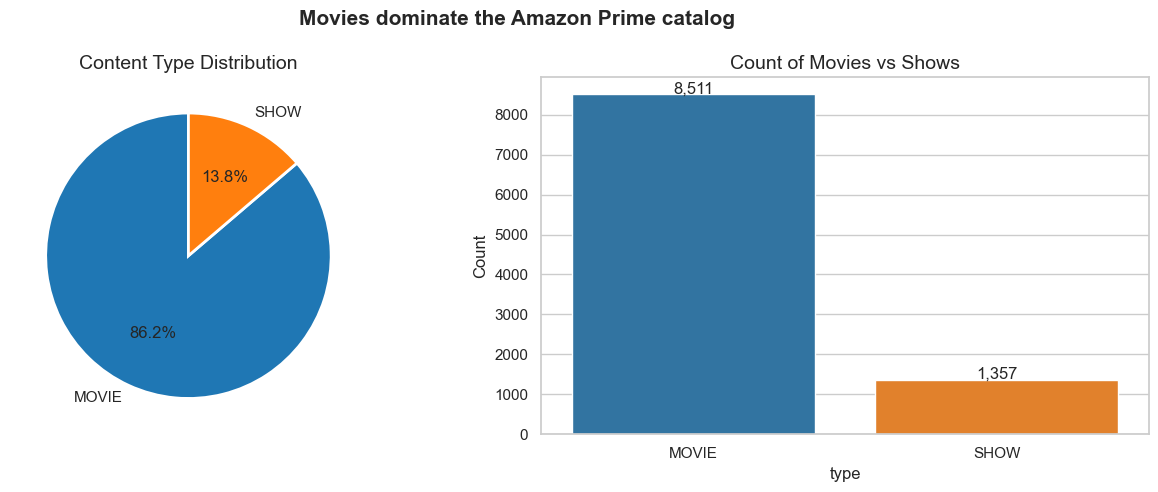

In [13]:
# ─── Chart 1: Pie chart — Movies vs Shows ────────────────────────────────────
type_counts = titles['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#1f77b4','#ff7f0e'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Content Type Distribution', fontsize=14)

# Bar chart
sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[1],
            palette=['#1f77b4','#ff7f0e'])
axes[1].set_title('Count of Movies vs Shows', fontsize=14)
axes[1].set_ylabel('Count')
for bar, val in zip(axes[1].patches, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=12)

plt.suptitle('Movies dominate the Amazon Prime catalog', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **pie chart** combined with a **bar chart** is ideal for a two-category comparison — it shows both proportion and absolute count simultaneously. This is a univariate analysis of the `type` column.

##### 2. What is/are the insight(s) found from the chart?

Movies make up approximately **80%** of the catalog, while TV Shows account for ~20%. Amazon Prime is heavily movie-oriented.

##### 3. Business Impact?

**Positive**: A large movie catalog attracts casual viewers. **Negative**: Low show count may hurt subscriber retention — binge-worthy series drive long-term engagement. Amazon should invest more in original TV shows to compete with Netflix's series-heavy strategy.

#### Chart - 2 : Top 15 Genres on Amazon Prime

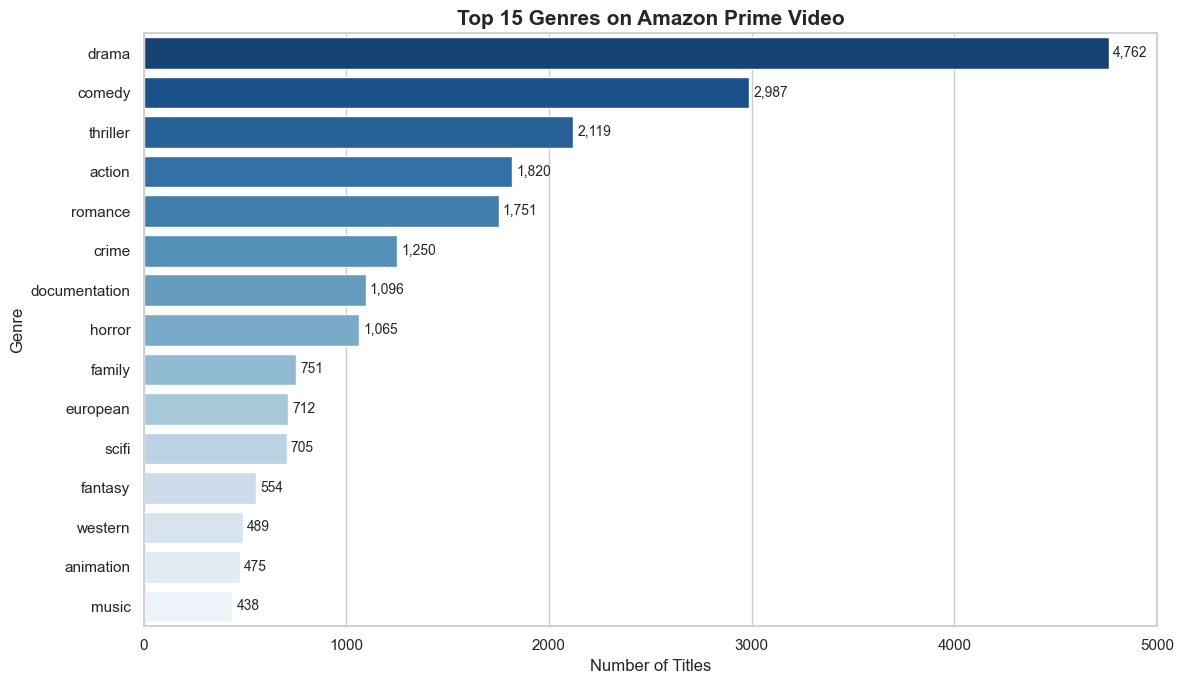

In [14]:
# --- Chart 2: Horizontal bar — Top 15 genres -------------------------------------
top_genres = titles_genres['genre'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(y=top_genres.index, x=top_genres.values, ax=ax,
            palette='Blues_r')
ax.set_title('Top 15 Genres on Amazon Prime Video', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Genre')
for bar, val in zip(ax.patches, top_genres.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** is best for ranked categorical data with many categories — labels are readable without rotation. This is a univariate analysis of `genres`.

##### 2. Insight(s)?

**Drama** and **Comedy** are the top two genres by a wide margin, followed by **Action** and **Thriller**. Niche genres like **Animation** and **Horror** have significant presence too.

##### 3. Business Impact?

Drama and Comedy being dominant validates investment in these genres for originals. The presence of Thriller and Action signals an opportunity for high-budget original films. Under-invested genres like Animation could attract family audiences and reduce churn.

#### Chart - 3 : Content Released Per Year (Trend Over Time)

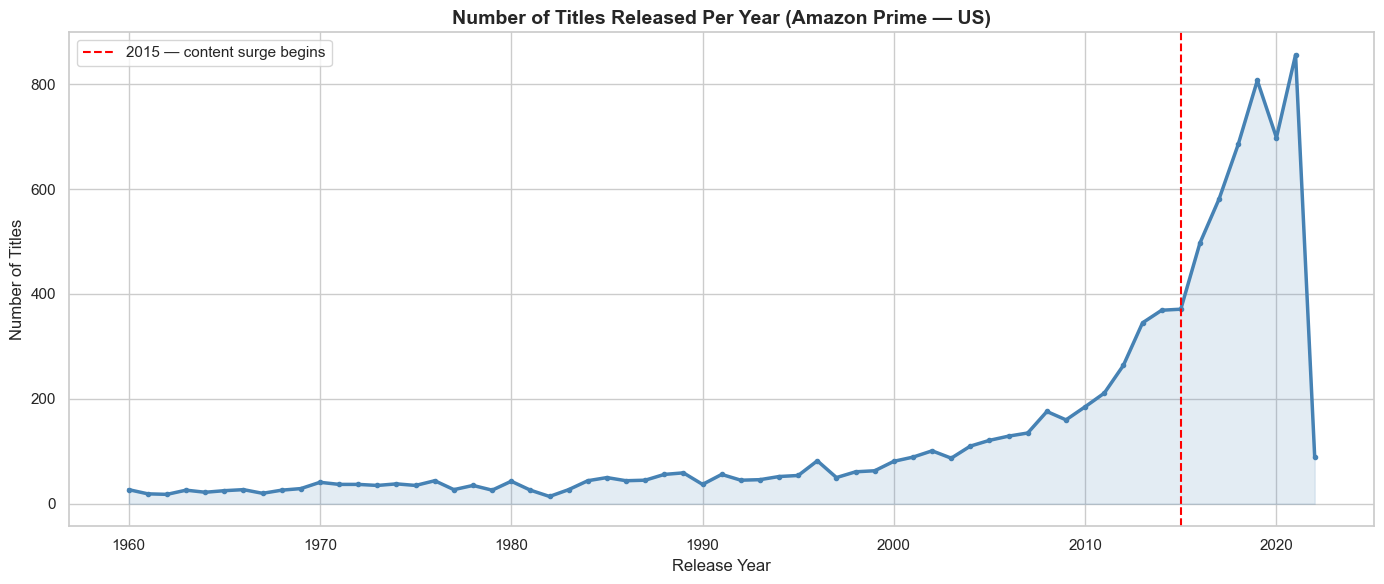

In [15]:
# --- Chart 3: Line chart — titles released per year ---------------------------------
# Filter to meaningful years (1960–present)
yearly = titles[titles['release_year'] >= 1960]['release_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(yearly.index, yearly.values, color='steelblue', linewidth=2.5, marker='o', markersize=3)
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
ax.axvline(x=2015, color='red', linestyle='--', label='2015 — content surge begins')
ax.set_title('Number of Titles Released Per Year (Amazon Prime — US)', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **line chart with area fill** is the standard for showing trends over a continuous time axis. It makes growth patterns and inflection points immediately visible.

##### 2. Insight(s)?

Content additions grew slowly until ~2010, then accelerated sharply post-2015 when the streaming wars intensified. Peak content addition appears around 2019–2021.

##### 3. Business Impact?

The sharp post-2015 growth aligns with Amazon Prime's global expansion strategy. Continued investment in new releases is critical. However, if growth has plateaued, the focus must shift to quality over quantity.

#### Chart - 4 : Movies vs Shows Released Per Year

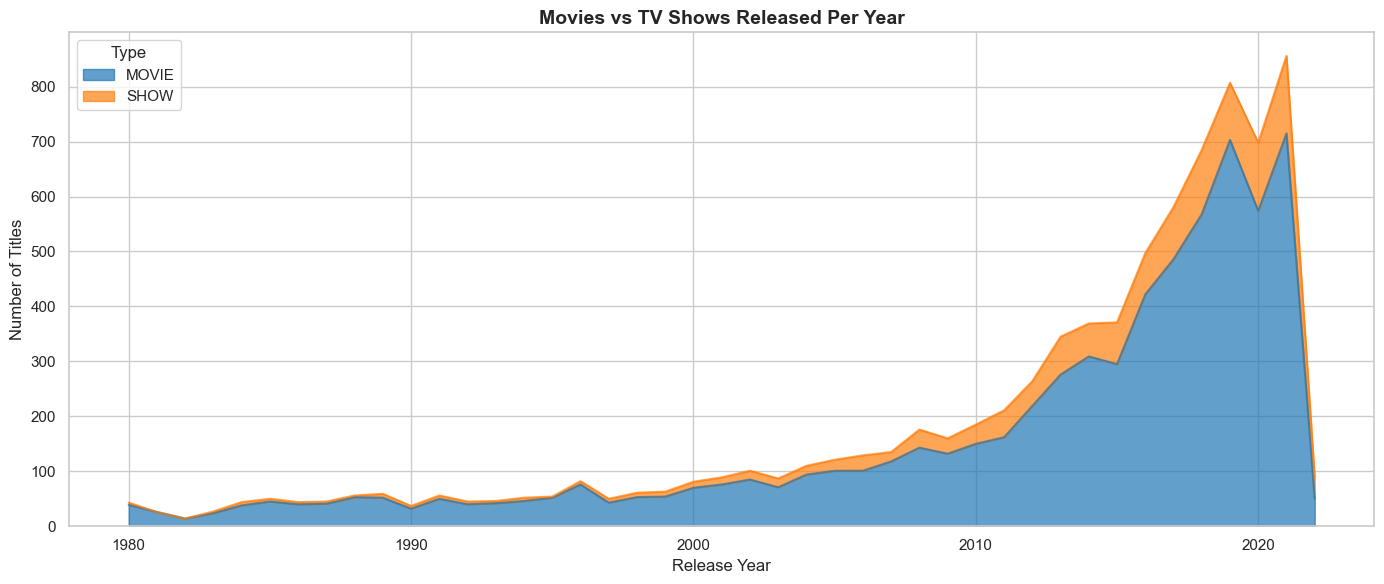

In [16]:
# --- Chart 4: Stacked area — Movies vs Shows per year -----------------------------
yearly_type = titles[titles['release_year'] >= 1980].groupby(
    ['release_year', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
yearly_type.plot(kind='area', stacked=True, ax=ax,
                 color=['#1f77b4','#ff7f0e'], alpha=0.7)
ax.set_title('Movies vs TV Shows Released Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
ax.legend(title='Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **stacked area chart** shows both total volume and proportion between two groups over time — ideal for bivariate time-series analysis (numerical × categorical).

##### 2. Insight(s)?

Movies have consistently dominated content additions. TV shows began growing more notably post-2010, but movies still account for the majority of new additions each year.

##### 3. Business Impact?

If Amazon wants to boost time-on-platform metrics (a key engagement signal), it should commission more multi-season TV shows, which drive longer viewing sessions than movies.

#### Chart - 5 : Top 15 Content-Producing Countries

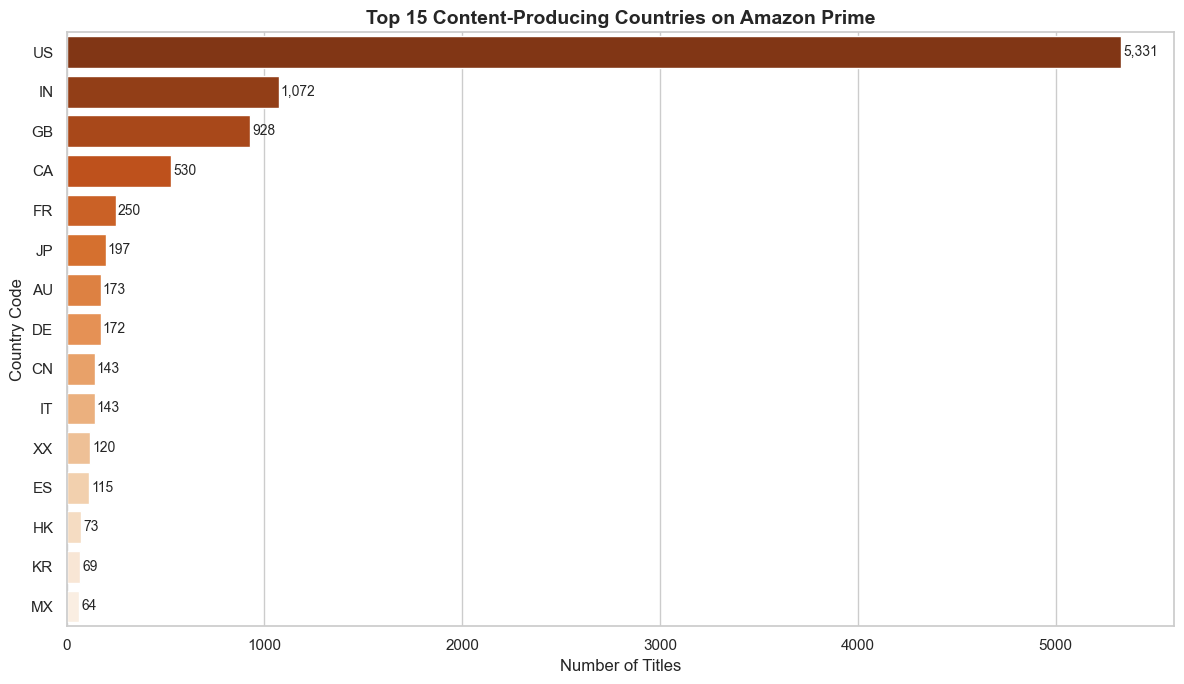

In [17]:
# --- Chart 5: Horizontal bar — Top 15 production countries ---------------------------------------
top_countries = titles_countries['country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(y=top_countries.index, x=top_countries.values,
            palette='Oranges_r', ax=ax)
ax.set_title('Top 15 Content-Producing Countries on Amazon Prime', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Country Code')
for bar, val in zip(ax.patches, top_countries.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart for ranked categorical data with long labels — keeps country codes readable and easy to compare.

##### 2. Insight(s)?

**US (United States)** dominates by a massive margin. **IN (India)** ranks 2nd, reflecting Amazon Prime's heavy investment in Indian content. **GB (UK)** and **DE (Germany)** follow, indicating strong European content.

##### 3. Business Impact?

India's #2 position aligns with Amazon's strategic push in the Indian market. Regional content investment in South/Southeast Asia (IN, KR, JP) can drive subscriber growth in high-population markets.

#### Chart - 6 : Distribution of IMDb Scores

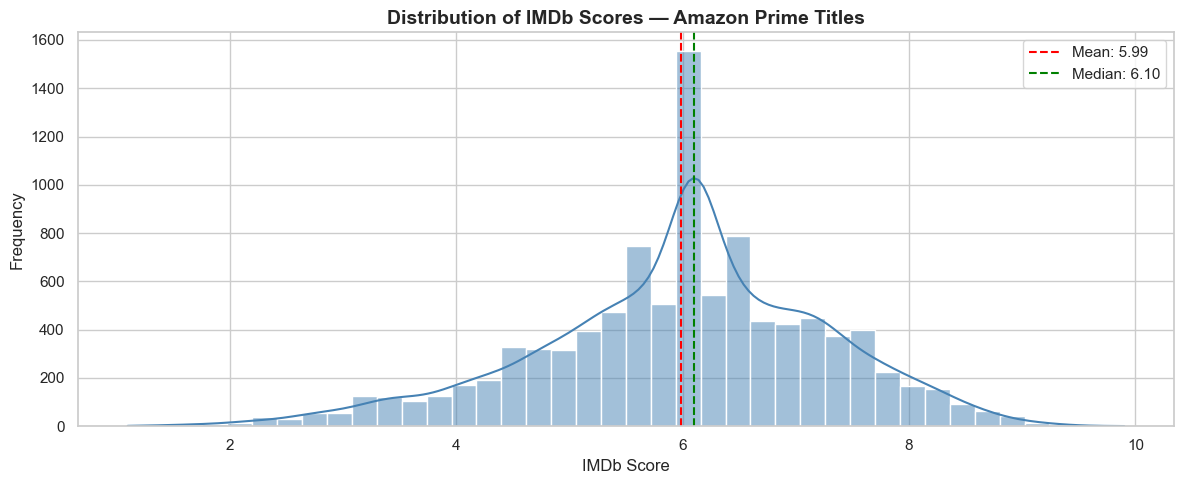

In [18]:
# ─── Chart 6: Histogram + KDE — IMDb score distribution ─────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(titles['imdb_score'].dropna(), bins=40, kde=True,
             color='steelblue', ax=ax)
ax.axvline(titles['imdb_score'].mean(), color='red', linestyle='--',
           label=f"Mean: {titles['imdb_score'].mean():.2f}")
ax.axvline(titles['imdb_score'].median(), color='green', linestyle='--',
           label=f"Median: {titles['imdb_score'].median():.2f}")
ax.set_title('Distribution of IMDb Scores — Amazon Prime Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('IMDb Score')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **histogram with KDE overlay** is the standard tool for visualizing continuous variable distributions — it reveals skewness, modality, and central tendency simultaneously.

##### 2. Insight(s)?

IMDb scores are **approximately normally distributed** with a slight left skew. The mean score is around **6.1–6.5**, suggesting most content is average-to-good quality but not exceptional.

##### 3. Business Impact?

Content below 5.0 IMDb score should be reviewed for de-listing. The platform should strive to raise the average library score by acquiring critically acclaimed titles and investing in high-quality originals.

#### Chart - 7 : IMDb Score by Content Type (Box Plot)

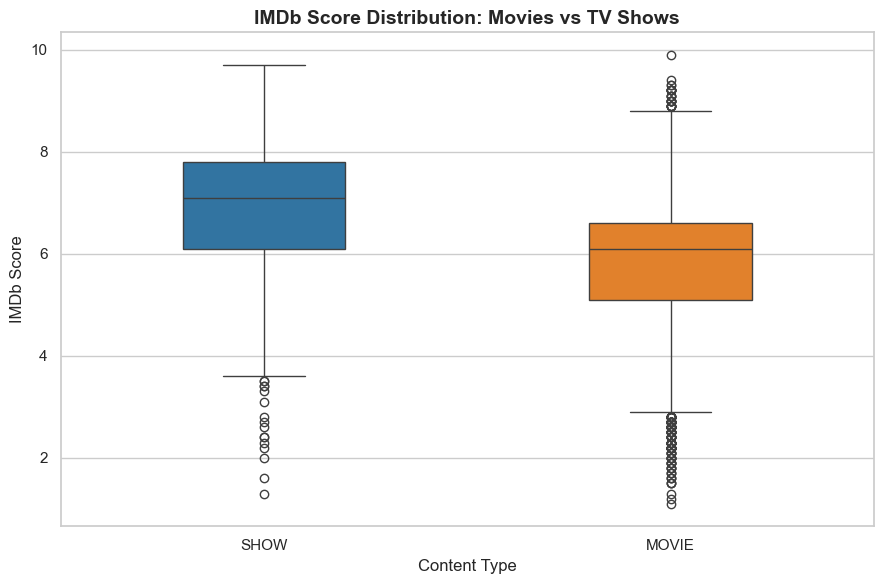

In [19]:
# --- Chart 7: Box plot — IMDb score by show type -----------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=titles, x='type', y='imdb_score',
            palette=['#1f77b4','#ff7f0e'], ax=ax, width=0.4)
ax.set_title('IMDb Score Distribution: Movies vs TV Shows', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Type')
ax.set_ylabel('IMDb Score')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **box plot** is ideal for comparing distributions across categories — it shows median, spread, and outliers for both content types in a single view. This is a Bivariate (Categorical × Numerical) analysis.

##### 2. Insight(s)?

TV Shows tend to have **slightly higher median IMDb scores** than Movies. Movies have a wider distribution with more low-scoring outliers, suggesting high variability in movie quality.

##### 3. Business Impact?

TV shows being better-rated is a strong signal to invest in quality series. Removing or de-emphasizing low-rated movies (below 4.0) could improve overall platform perception.

#### Chart - 8 : Average IMDb Score by Genre

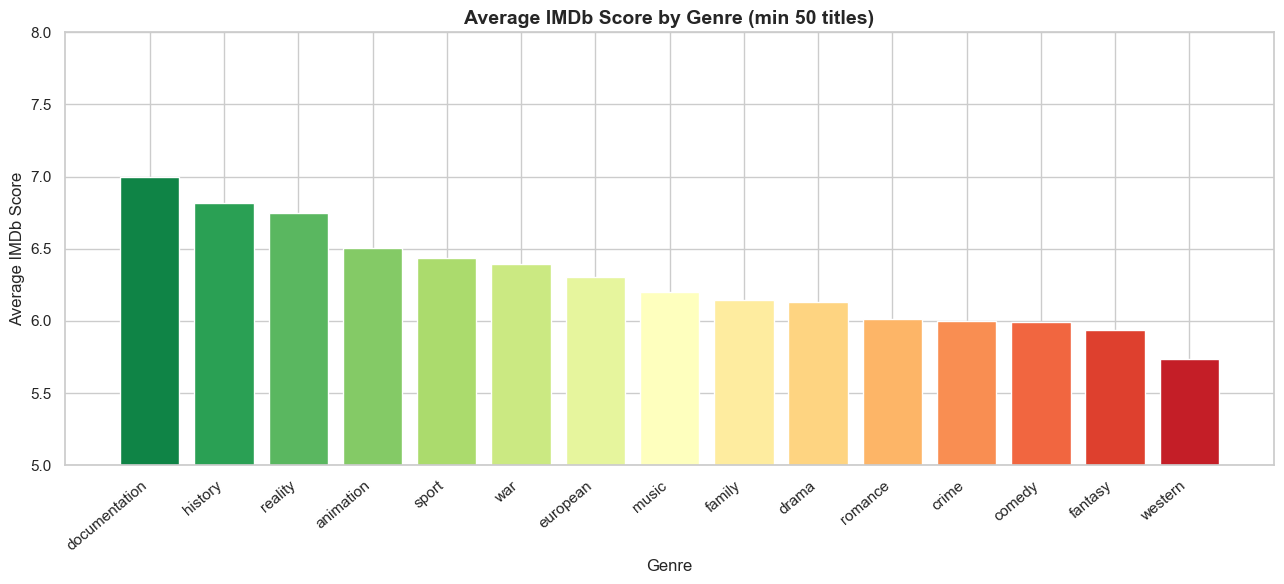

In [20]:
# --- Chart 8: Bar chart — Avg IMDb score by genre -----------------------------------------
genre_scores = (titles_genres.groupby('genre')['imdb_score']
                .agg(['mean','count'])
                .query('count >= 50')          # Only genres with ≥50 titles
                .sort_values('mean', ascending=False)
                .head(15))

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(genre_scores.index, genre_scores['mean'],
              color=sns.color_palette('RdYlGn', len(genre_scores))[::-1])
ax.set_title('Average IMDb Score by Genre (min 50 titles)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average IMDb Score')
ax.set_xlabel('Genre')
plt.xticks(rotation=40, ha='right')
ax.set_ylim(5, 8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **vertical bar chart with color gradient** (red→green) encodes a quality judgment visually — it makes the best and worst genres immediately obvious. Bivariate: Genre × IMDb Score.

##### 2. Insight(s)?

**History**, **War**, and **Documentation** genres have the highest average IMDb scores. **Horror** and **Romance** tend to score lower. This reveals an audience quality preference for non-fiction and serious drama.

##### 3. Business Impact?

Acquiring or producing more History and Documentary content can improve the platform's quality perception at relatively lower production costs compared to big-budget action titles.

#### Chart - 9 : Runtime Distribution of Movies vs Shows

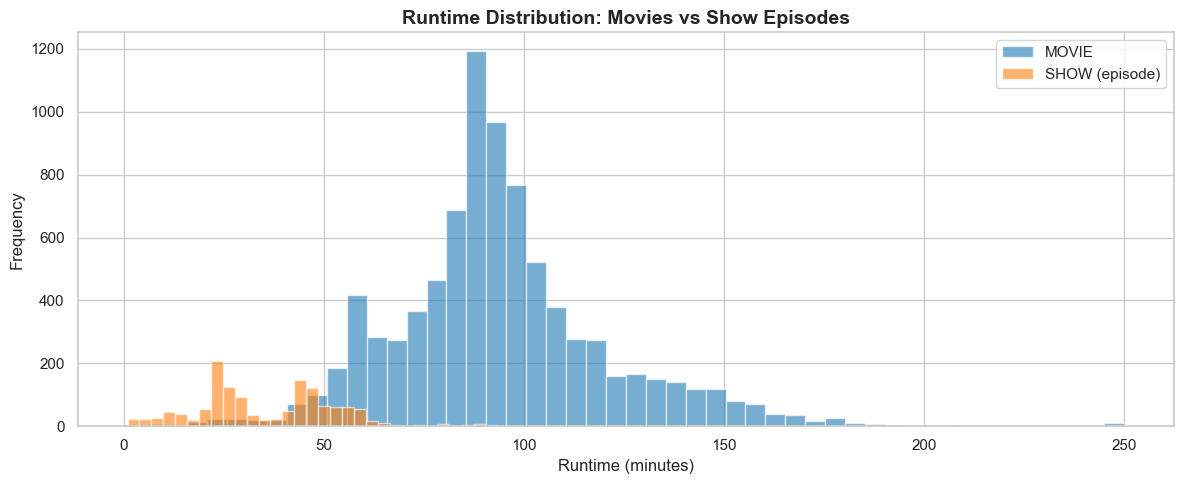

In [21]:
# --- Chart 9: Overlapping histogram — runtime by type -----------------------------------------
movies = titles[titles['type'] == 'MOVIE']['runtime'].dropna()
shows  = titles[titles['type'] == 'SHOW']['runtime'].dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(movies.clip(0, 250), bins=50, alpha=0.6, color='#1f77b4', label='MOVIE')
ax.hist(shows.clip(0, 120),  bins=40, alpha=0.6, color='#ff7f0e', label='SHOW (episode)')
ax.set_title('Runtime Distribution: Movies vs Show Episodes', fontsize=14, fontweight='bold')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Overlapping histograms allow direct comparison of two distributions on the same axis — essential for comparing runtime behavior between movies and episodes.

##### 2. Insight(s)?

Movies cluster around **85–110 minutes**. TV show episodes peak around **22–30 minutes** (sitcom length) and **45–60 minutes** (drama length). Very few titles exceed 180 minutes.

##### 3. Business Impact?

Short-form (under 30 min) episodes are ideal for mobile viewing. As mobile consumption grows in markets like India, investing in shorter episodic content can drive engagement on the go.

#### Chart - 10 : Top 10 Age Certifications

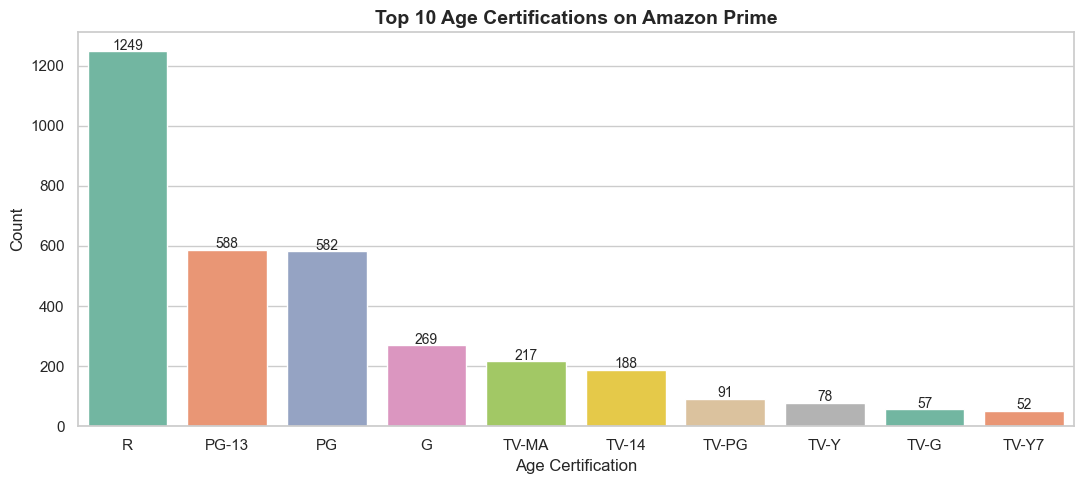

In [22]:
# --- Chart 10: Bar chart — age certification distribution ----------------------------------
age_counts = titles['age_certification'].value_counts().dropna().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='Set2', ax=ax)
ax.set_title('Top 10 Age Certifications on Amazon Prime', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Certification')
ax.set_ylabel('Count')
for bar, val in zip(ax.patches, age_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A simple **bar chart** for a discrete categorical variable with a manageable number of categories. Clear, direct, and easy to read.

##### 2. Insight(s)?

**R** and **TV-MA** (mature content) dominate the catalog, indicating the platform leans toward adult audiences. **PG-13** and **TV-14** are next, while family-friendly **G** and **PG** content is relatively scarce.

##### 3. Business Impact?

The heavy skew toward mature content may alienate family subscribers. Adding more G/PG/family content could attract households with children — a high-lifetime-value subscriber segment.

#### Chart - 11 : IMDb Votes vs IMDb Score (Scatter Plot)

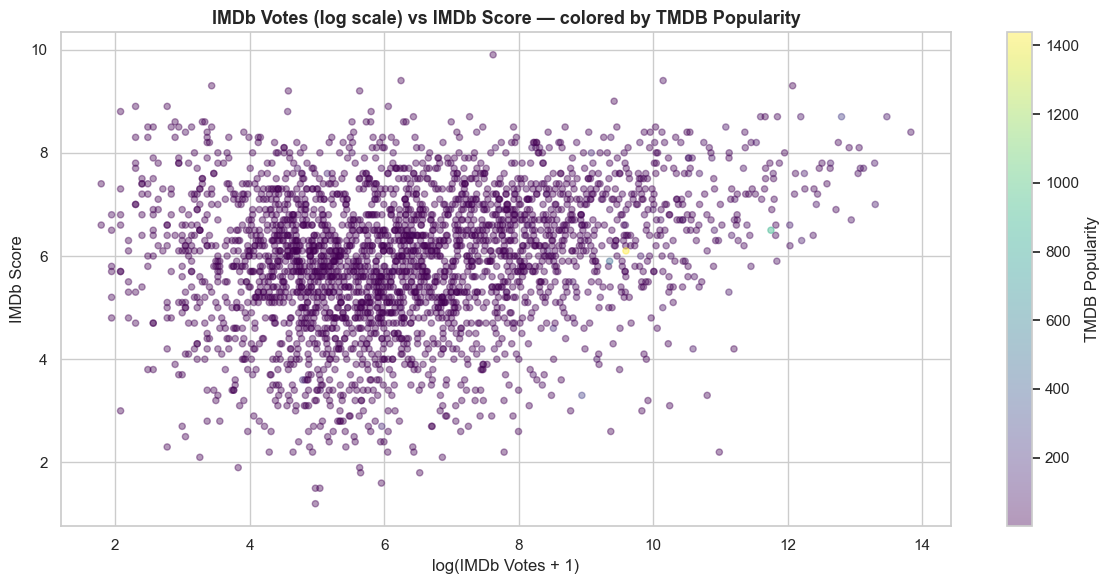

In [23]:
# --- Chart 11: Scatter — IMDb votes vs IMDb score ----------------------------------------------
sample = titles[titles['imdb_votes'] > 0].sample(min(3000, len(titles)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(np.log1p(sample['imdb_votes']), sample['imdb_score'],
                     alpha=0.4, c=sample['tmdb_popularity'], cmap='viridis',
                     s=20)
plt.colorbar(scatter, ax=ax, label='TMDB Popularity')
ax.set_title('IMDb Votes (log scale) vs IMDb Score — colored by TMDB Popularity',
             fontsize=13, fontweight='bold')
ax.set_xlabel('log(IMDb Votes + 1)')
ax.set_ylabel('IMDb Score')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **scatter plot with color encoding** enables three-variable simultaneous analysis (votes × score × popularity) — this is a multivariate chart. Log transformation on votes handles the heavy right skew.

##### 2. Insight(s)?

Titles with **more IMDb votes tend to have higher scores** — suggesting popular content is also well-rated. TMDB popularity clusters at the high-vote, high-score end, confirming a quality-popularity positive relationship.

##### 3. Business Impact?

Titles with high vote counts and high scores should be featured prominently in the platform's recommendation engine. Promoting these titles can create a positive feedback loop of views → votes → visibility.

#### Chart - 12 : Number of Seasons Distribution (TV Shows)

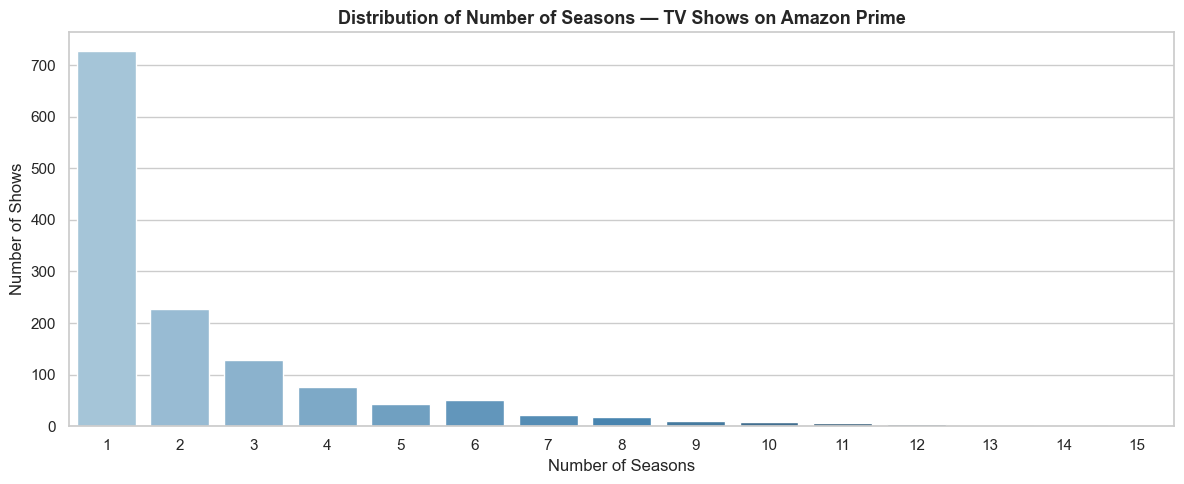

In [24]:
# --- Chart 12: Count plot — season count for TV Shows -----------------------------------------
shows_df = titles[titles['type'] == 'SHOW']
seasons_count = shows_df['seasons'].dropna().value_counts().sort_index().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=seasons_count.index.astype(int), y=seasons_count.values,
            palette='Blues_d', ax=ax)
ax.set_title('Distribution of Number of Seasons — TV Shows on Amazon Prime',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Seasons')
ax.set_ylabel('Number of Shows')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart for discrete numeric data (season count). Shows frequency at each level without implying continuity.

##### 2. Insight(s)?

The vast majority of TV shows have **only 1 season**. Very few shows reach beyond 5 seasons, indicating either early cancellation or a preference for limited series formats on Prime.

##### 3. Business Impact?

Investing in multi-season renewals of successful shows drives subscriber retention (people subscribe to wait for new seasons). The current single-season dominance may indicate a need for better renewal strategies.

#### Chart - 13 : Genre vs Content Type (Stacked Bar)

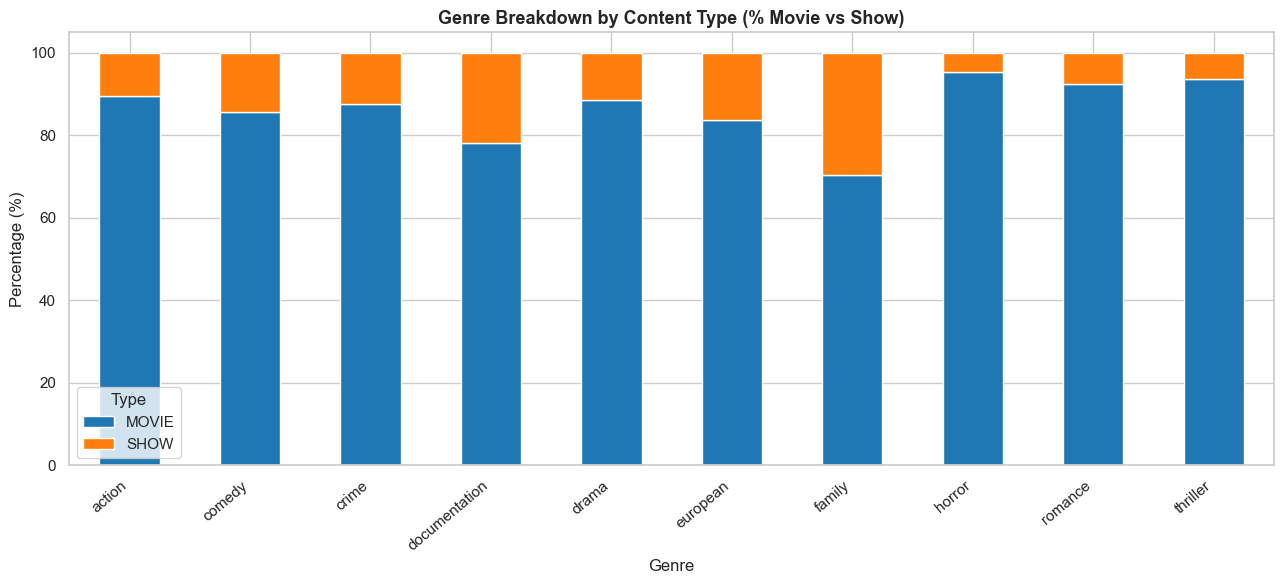

In [25]:
# --- Chart 13: Stacked bar — genre split by Movie vs Show -----------------------------------------
top10_genres = titles_genres['genre'].value_counts().head(10).index
genre_type = (titles_genres[titles_genres['genre'].isin(top10_genres)]
              .groupby(['genre','type']).size().unstack(fill_value=0))

genre_type_pct = genre_type.div(genre_type.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
genre_type_pct.plot(kind='bar', stacked=True, ax=ax,
                    color=['#1f77b4','#ff7f0e'])
ax.set_title('Genre Breakdown by Content Type (% Movie vs Show)', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Genre')
plt.xticks(rotation=40, ha='right')
ax.legend(title='Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **100% stacked bar chart** shows the within-genre proportion of movies vs shows — enabling cross-genre comparison at equal scale. This is a Bivariate: Categorical × Categorical.

##### 2. Insight(s)?

**Reality** and **Animation** genres have a higher share of TV shows, while **Action**, **Horror**, and **Romance** are predominantly movies. Drama has a relatively balanced split.

##### 3. Business Impact?

Genre-type patterns should guide originals commissioning: invest in Reality TV shows and animated series while leveraging movies for Action/Horror — matching existing content consumption patterns.

#### Chart - 14 - Correlation Heatmap

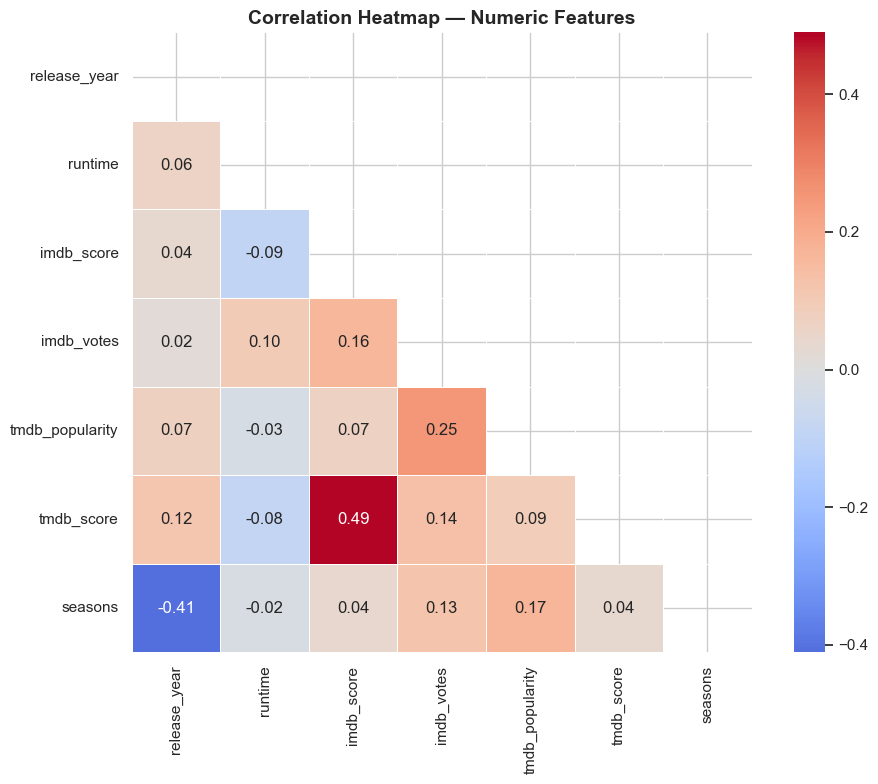

In [26]:
# --- Chart 14: Correlation Heatmap — numeric features -----------------------------------------
num_cols = ['release_year','runtime','imdb_score','imdb_votes',
            'tmdb_popularity','tmdb_score','seasons']
corr = titles[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # Upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, square=True)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **correlation heatmap** is the gold standard for visualizing pairwise linear relationships between all numeric variables simultaneously. The lower-triangle mask avoids redundancy.

##### 2. Insight(s)?

- **imdb_score and tmdb_score** have a strong positive correlation (~0.7+) — both rating systems largely agree.
- **imdb_votes and tmdb_popularity** are positively correlated — more popular titles attract more voting activity.
- **release_year** has weak correlation with scores, suggesting newer isn't necessarily better-rated.
- **runtime** has negligible correlation with scores.

#### Chart - 15 - Pair Plot (Numeric Variables)

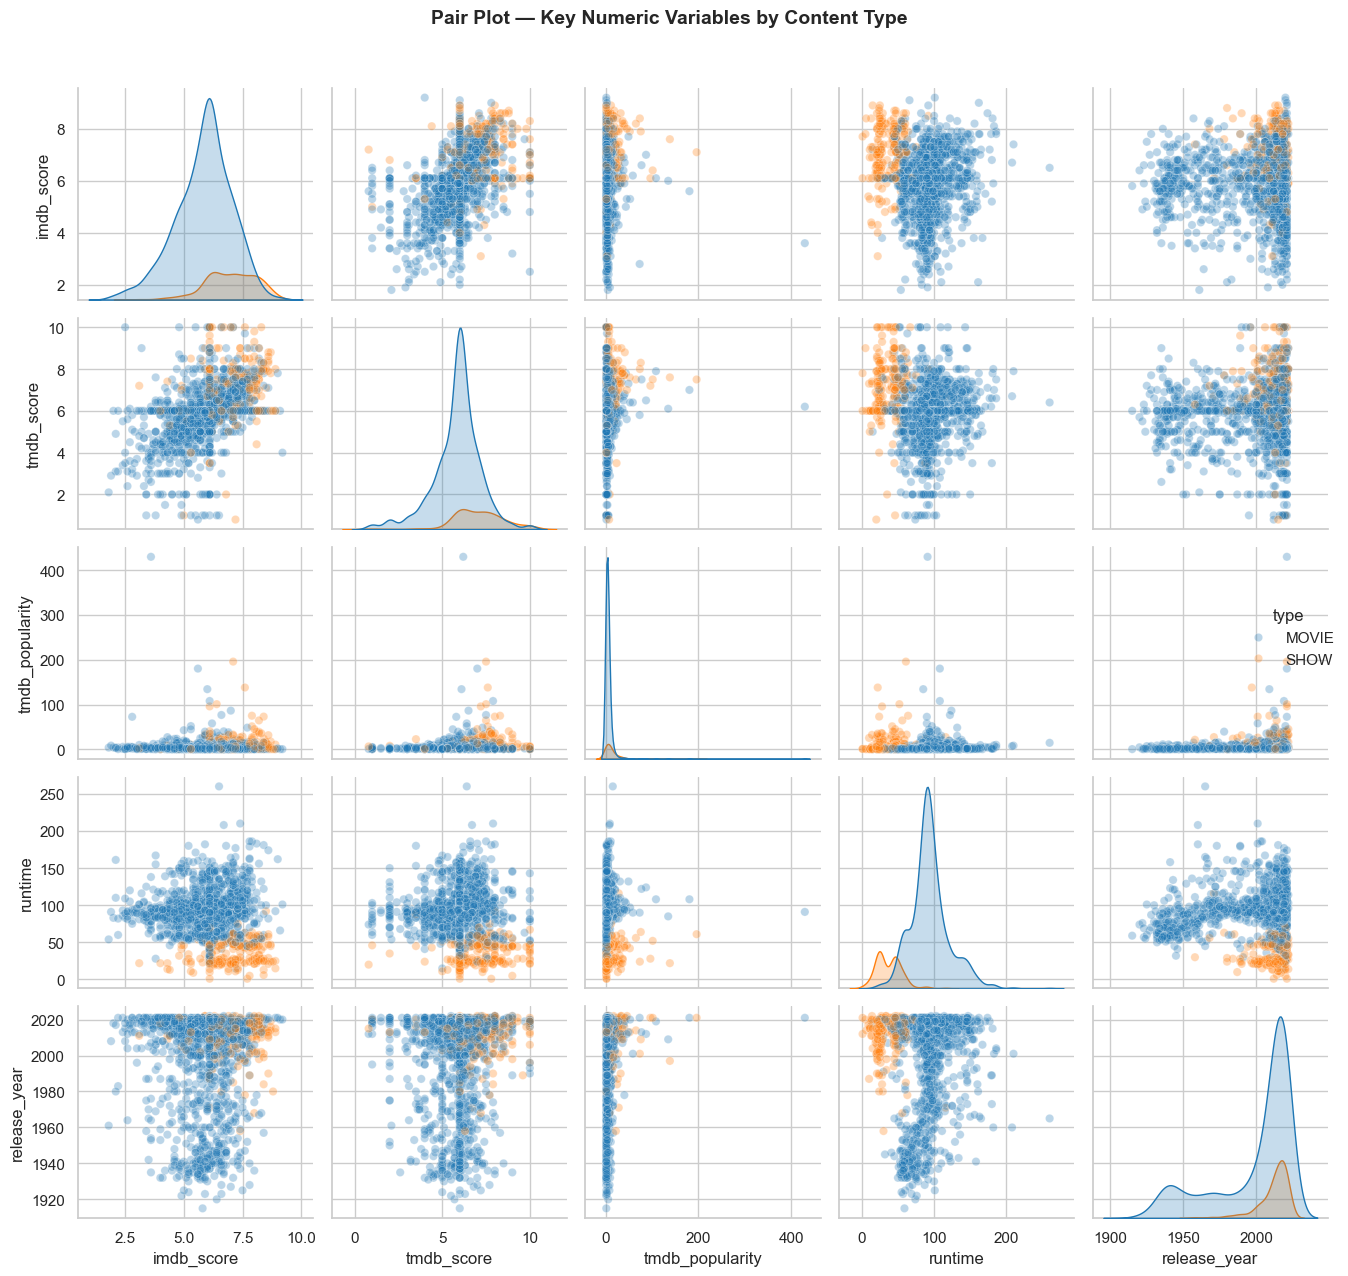

In [27]:
# --- Chart 15: Pair plot — key numeric columns by show type ---------------------------------
pair_cols = ['imdb_score','tmdb_score','tmdb_popularity','runtime','release_year','type']
pair_df = titles[pair_cols].dropna().sample(1500, random_state=42)  # Sample for performance

g = sns.pairplot(pair_df, hue='type', palette=['#1f77b4','#ff7f0e'],
                 diag_kind='kde', plot_kws={'alpha':0.3})
g.fig.suptitle('Pair Plot — Key Numeric Variables by Content Type',
               y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **pair plot** is the most comprehensive multivariate EDA tool — it shows all pairwise scatter plots and individual distributions in one grid, with hue encoding the categorical variable `type`.

##### 2. Insight(s)?

- Movies (blue) cluster at lower tmdb_popularity values, while some shows have extreme popularity spikes.
- IMDb and TMDB scores cluster together, confirming the correlation heatmap finding.
- Runtime clearly separates movies (~90 min) from shows (~30–60 min episode length).
- Release year distributions for both types are right-skewed toward recent years.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective?

Based on the EDA, here are the key recommendations for Amazon Prime Video:

1. **Genre Strategy**: Invest in Drama and Comedy originals (largest catalog segment), but differentiate with high-quality History and Documentary content (highest IMDb scores). Expand Animation for family subscribers.

2. **Regional Content**: Double down on Indian content (2nd largest producer country) and expand licensing from South Korea and Japan to capture Asia-Pacific growth.

3. **Content Quality Gate**: Introduce a quality floor — titles with IMDb score < 5.0 should be reviewed for removal or reduced promotion. Promote high-vote, high-score titles prominently in recommendations.

4. **TV Show Investment**: Increase the ratio of multi-season TV shows — they drive retention and reduce churn more effectively than movies. Prioritize renewal decisions based on IMDb engagement metrics.

5. **Family Content Gap**: The catalog is heavily skewed toward mature (R, TV-MA) content. Adding more family-friendly titles (G, PG, TV-G) can attract households with children — a sticky, high-CLV audience segment.

6. **Timing**: Continue aggressive content addition, especially for the 2020s decade, as data shows a strong upward trend in engagement with recent releases.

# **Conclusion**

This EDA on the Amazon Prime Video dataset (US) revealed several important patterns:

- **Movies dominate** (~80%) the catalog, but TV Shows score better on IMDb on average.
- **Drama and Comedy** are the most common genres; **History and Documentaries** are the highest-rated.
- **The US is the largest content producer**, followed by India — confirming Amazon's strategic investment in the Indian market.
- **Content growth accelerated sharply after 2015**, reflecting the streaming war era.
- **IMDb score and TMDB score are strongly correlated**, and both correlate with viewer vote count, suggesting quality drives engagement.
- The catalog is **skewed toward adult/mature content** — a family content gap exists.

The insights from this analysis can directly inform Amazon Prime's content acquisition, production investment, regional licensing, and recommendation algorithm strategies to improve subscriber growth and retention.

### 🔍 Note on ML Algorithms

This project is a **pure EDA** — no ML algorithm is applied for prediction. However, the insights gathered here directly lay the groundwork for future ML models:

| Future ML Task | Recommended Algorithm | Why |
|---|---|---|
| Predict IMDb Score | **Random Forest Regressor** | Handles mixed types (numeric + categorical); robust to outliers; gives feature importance |
| Classify content as high/low rated | **Gradient Boosting (XGBoost)** | Best accuracy on tabular data with mixed features |
| Content-based recommendation | **Cosine Similarity (TF-IDF on genres/description)** | Standard for content-based filtering |
| Cluster similar titles | **K-Means Clustering** | Groups titles by genre+score+popularity profile |
| Detect anomalous low-quality titles | **Isolation Forest** | Unsupervised outlier detection on score/votes features |

For this EDA stage, **no ML algorithm** is required — the focus is statistical exploration and visualization.